# Ranked EV Charging Station Recommendations

## tl;dr

This notebook converts the suitability, gap, environmental-screening, and port-demand results into a **first-phase deployment shortlist**. It recommends:

- destination Level 2 locations,
- DC fast-charging planning zones,
- initial and expansion port counts,
- charging power categories, and
- connector mixes.

The recommendations are planning concepts. Level 2 records are mapped OpenStreetMap parking opportunities; DC fast records are high-priority planning zones represented by Census block-group points. Neither is a construction-ready parcel.

## Context & Methods

### Decision rules

**Level 2**

- Use only environmentally eligible candidates with no protected-land review flag.
- Combine screened site suitability with the surrounding community charging-gap score.
- Recommend 6–12 initial ports depending on score, with expansion capacity.
- Use destination-oriented AC charging, generally 11.5–19.2 kW per port.

**DC fast**

- Combine corridor demand, DC fast access gap, public-access need, and traffic.
- Select geographically separated planning zones to avoid clustering recommendations.
- Use a minimum conceptual build of four ports, increasing to six or eight at stronger locations.
- Recommend 150–350 kW equipment, with expansion capacity.

**Connector strategy**

- Level 2: J1772 and J3400/NACS.
- DC fast: CCS1 and J3400/NACS.
- CHAdeMO is retained in the existing-infrastructure inventory but is not recommended for new first-phase installations.

### Important scope boundary

The regional deficits modeled in Notebook 09 are much larger than this shortlist. Port counts here describe a credible **first deployment phase**, not full build-out of the seven-county need.

## Data

### 1. Setup and load inputs

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"

PROJECTED_CRS = "EPSG:26916"
DC_ZONE_COUNT = 12
MIN_DC_SEPARATION_MILES = 10
METERS_PER_MILE = 1609.344

level2 = gpd.read_file(SPATIAL_DIR / "level2_candidate_shortlist.gpkg")
gaps = gpd.read_file(SPATIAL_DIR / "charging_gap_block_groups.gpkg")
corridor = gpd.read_file(SPATIAL_DIR / "dc_fast_corridor_demand.gpkg")
study_area = gpd.read_file(SPATIAL_DIR / "study_area_counties.gpkg")
demand = pd.read_csv(TABLE_DIR / "charging_port_demand_by_county.csv")
moderate_demand = demand.loc[demand["scenario"] == "Moderate (12%)"].copy()

assert level2["candidate_id"].is_unique
assert gaps["GEOID"].is_unique
assert corridor["GEOID"].is_unique
assert moderate_demand["county_name"].is_unique

print(f"Environmentally eligible Level 2 candidates: {len(level2)}")
print(f"Candidates without protected-land review: {(~level2['protected_land_review']).sum()}")
print(f"DC fast planning units: {len(corridor):,}")

Environmentally eligible Level 2 candidates: 26
Candidates without protected-land review: 16
DC fast planning units: 926


## Results

### 2. Rank clear Level 2 candidates

In [2]:
clear_l2 = level2.loc[
    level2["environmentally_eligible"] & ~level2["protected_land_review"]
].copy()

gap_attributes = gaps[[
    "GEOID", "community_gap_score", "market_gap_score",
    "public_access_need_index", "population"
]].copy()
clear_l2 = clear_l2.drop(
    columns=[
        column for column in gap_attributes.columns
        if column != "GEOID" and column in clear_l2.columns
    ],
    errors="ignore",
)
clear_l2 = clear_l2.merge(
    gap_attributes, on="GEOID", how="left", validate="many_to_one"
)

clear_l2["level2_recommendation_score"] = (
    0.55 * clear_l2["screened_site_score"]
    + 0.30 * clear_l2["community_gap_score"]
    + 0.15 * clear_l2["market_gap_score"]
)
clear_l2["recommendation_type"] = "Level 2 destination"
clear_l2["initial_ports"] = np.select(
    [
        clear_l2["level2_recommendation_score"] >= 75,
        clear_l2["level2_recommendation_score"] >= 68,
        clear_l2["level2_recommendation_score"] >= 60,
    ],
    [12, 10, 8],
    default=6,
).astype(int)
clear_l2["expansion_ports"] = clear_l2["initial_ports"] + 4
clear_l2["power_recommendation"] = "11.5–19.2 kW AC Level 2"
clear_l2["connector_mix"] = "J1772 + J3400/NACS"
clear_l2["site_status"] = "Mapped parking opportunity; parcel verification required"
clear_l2["location_label"] = (
    clear_l2["county_name"] + " " + clear_l2["candidate_id"]
)
clear_l2 = clear_l2.sort_values(
    ["level2_recommendation_score", "candidate_id"],
    ascending=[False, True],
).reset_index(drop=True)
clear_l2["technology_rank"] = np.arange(1, len(clear_l2) + 1)

clear_l2[[
    "technology_rank", "candidate_id", "county_name",
    "destination_type", "level2_recommendation_score",
    "initial_ports", "expansion_ports",
]].head(10)

,technology_rank,candidate_id,county_name,destination_type,level2_recommendation_score,initial_ports,expansion_ports
0,1,L2-0020,Clarke,Parking,69.548935,10,14
1,2,L2-0021,Clarke,Parking,69.548935,10,14
2,3,L2-0015,Clarke,Parking,61.334960,8,12
3,4,L2-0016,Clarke,Parking,61.334960,8,12
4,5,L2-0024,Clarke,Parking,61.334960,8,12
5,6,L2-0025,Clarke,Parking,61.334960,8,12
6,7,L2-0008,Jackson,Parking,60.839471,8,12
7,8,L2-0017,Jackson,Parking,60.839471,8,12
8,9,L2-0014,Clarke,Parking,60.746526,8,12
9,10,L2-0027,Barrow,Parking,57.421113,6,10


### 3. Rank and spatially separate DC fast planning zones

In [3]:
dc = corridor.copy()
dc["dc_recommendation_score"] = (
    0.40 * dc["dc_corridor_score"]
    + 0.35 * dc["dc_fast_gap_score"]
    + 0.15 * dc["public_access_need_index"]
    + 0.10 * dc["traffic_volume_score"]
)
dc["geometry"] = dc.geometry.representative_point()
dc = dc.to_crs(PROJECTED_CRS)
dc = dc.sort_values(
    ["dc_recommendation_score", "GEOID"], ascending=[False, True]
)

selected_indices = []
minimum_distance = MIN_DC_SEPARATION_MILES * METERS_PER_MILE

# First select the strongest zone in every county to preserve regional coverage.
for county in sorted(dc["county_name"].unique()):
    county_options = dc.loc[dc["county_name"] == county]
    if not county_options.empty:
        selected_indices.append(county_options.index[0])

# Fill remaining positions by score while enforcing separation from selected zones.
for index, candidate in dc.iterrows():
    if index in selected_indices:
        continue
    distances = dc.loc[selected_indices].geometry.distance(candidate.geometry)
    if distances.min() >= minimum_distance:
        selected_indices.append(index)
    if len(selected_indices) >= DC_ZONE_COUNT:
        break

dc_selected = dc.loc[selected_indices].copy()
dc_selected = dc_selected.sort_values(
    ["dc_recommendation_score", "GEOID"], ascending=[False, True]
).head(DC_ZONE_COUNT)
dc_selected["recommendation_type"] = "DC fast planning zone"
dc_selected["initial_ports"] = np.select(
    [
        (dc_selected["aadt_value"] >= 100_000)
        | (dc_selected["dc_recommendation_score"] >= 82),
        (dc_selected["aadt_value"] >= 50_000)
        | (dc_selected["dc_recommendation_score"] >= 72),
    ],
    [8, 6],
    default=4,
).astype(int)
dc_selected["expansion_ports"] = dc_selected["initial_ports"] * 2
dc_selected["power_recommendation"] = np.where(
    (dc_selected["aadt_value"] >= 100_000)
    | (dc_selected["dc_recommendation_score"] >= 82),
    "250–350 kW DC fast",
    "150–250 kW DC fast",
)
dc_selected["connector_mix"] = "CCS1 + J3400/NACS"
dc_selected["site_status"] = "Planning zone; exact parcel and utility verification required"
dc_selected["location_label"] = (
    dc_selected["county_name"] + " zone " + dc_selected["GEOID"].str[-4:]
)
dc_selected = dc_selected.reset_index(drop=True)
dc_selected["technology_rank"] = np.arange(1, len(dc_selected) + 1)

dc_selected[[
    "technology_rank", "location_label", "county_name",
    "dc_recommendation_score", "aadt_value", "nearest_dc_fast_miles",
    "initial_ports", "expansion_ports", "power_recommendation",
]]

,technology_rank,location_label,county_name,dc_recommendation_score,aadt_value,nearest_dc_fast_miles,initial_ports,expansion_ports,power_recommendation
0,1,Gwinnett zone 3331,Gwinnett,79.702129,303000.0,1.559797,8,16,250–350 kW DC fast
1,2,Hall zone 6073,Hall,70.986473,67100.0,5.265770,6,12,150–250 kW DC fast
2,3,Gwinnett zone 7542,Gwinnett,70.654702,39400.0,3.667319,4,8,150–250 kW DC fast
3,4,Jackson zone 2002,Jackson,66.692372,52800.0,6.118490,6,12,150–250 kW DC fast
4,5,Jackson zone 1051,Jackson,61.560972,54200.0,3.943687,6,12,150–250 kW DC fast
5,6,Hall zone 5022,Hall,61.134399,26000.0,4.266773,4,8,150–250 kW DC fast
6,7,Walton zone 8011,Walton,60.582881,15900.0,15.590996,4,8,150–250 kW DC fast
7,8,Gwinnett zone 5721,Gwinnett,59.835256,33302.0,1.466974,4,8,150–250 kW DC fast
8,9,Clarke zone 7012,Clarke,59.323058,33700.0,1.686244,4,8,150–250 kW DC fast
9,10,Barrow zone 5032,Barrow,54.692788,31400.0,3.301011,4,8,150–250 kW DC fast


### 4. Compare the first phase with moderate-scenario regional gaps

In [4]:
phase_l2 = (
    clear_l2.groupby("county_name", as_index=False)["initial_ports"]
    .sum()
    .rename(columns={"initial_ports": "phase1_l2_ports"})
)
phase_dc = (
    dc_selected.groupby("county_name", as_index=False)["initial_ports"]
    .sum()
    .rename(columns={"initial_ports": "phase1_dc_fast_ports"})
)

phase_summary = (
    moderate_demand[[
        "county_name", "additional_l2_ports", "additional_dc_fast_ports"
    ]]
    .merge(phase_l2, on="county_name", how="left", validate="one_to_one")
    .merge(phase_dc, on="county_name", how="left", validate="one_to_one")
    .fillna({"phase1_l2_ports": 0, "phase1_dc_fast_ports": 0})
)
phase_summary["remaining_l2_planning_gap"] = (
    phase_summary["additional_l2_ports"] - phase_summary["phase1_l2_ports"]
).clip(lower=0).astype(int)
phase_summary["remaining_dc_fast_planning_gap"] = (
    phase_summary["additional_dc_fast_ports"]
    - phase_summary["phase1_dc_fast_ports"]
).clip(lower=0).astype(int)

phase_summary.sort_values("county_name")

,county_name,additional_l2_ports,additional_dc_fast_ports,phase1_l2_ports,phase1_dc_fast_ports,remaining_l2_planning_gap,remaining_dc_fast_planning_gap
0,Barrow,299,47,6.0,4,293,43
1,Clarke,593,67,60.0,4,533,63
2,Gwinnett,3263,457,12.0,16,3251,441
3,Hall,639,75,12.0,14,627,61
4,Jackson,313,53,22.0,12,291,41
5,Oconee,122,14,6.0,4,116,10
6,Walton,363,58,0.0,4,363,54


### 5. Create the combined recommendation map

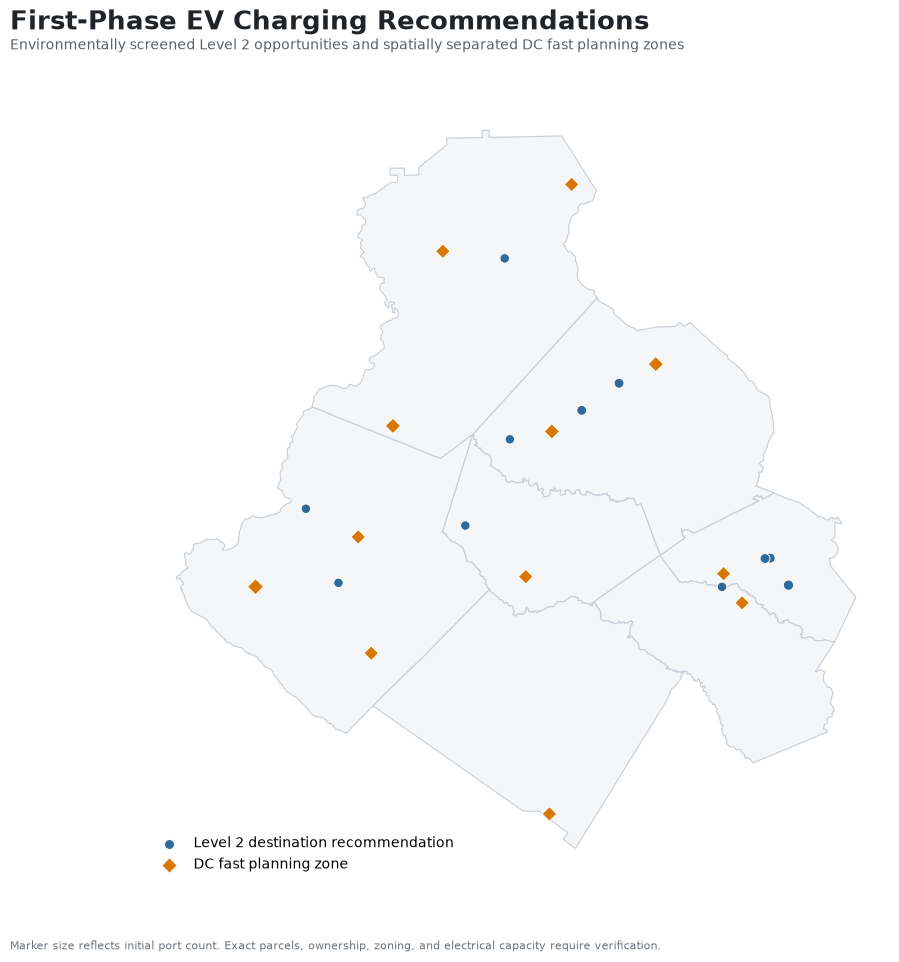

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\first_phase_ev_charging_recommendations.png


In [5]:
l2_map = clear_l2.to_crs(PROJECTED_CRS)
dc_map = dc_selected.to_crs(PROJECTED_CRS)
area_map = study_area.to_crs(PROJECTED_CRS)

fig, ax = plt.subplots(figsize=(11, 10), facecolor="white")
area_map.plot(
    ax=ax, color="#F4F6F8", edgecolor="#C8CED6", linewidth=0.8
)
l2_map.plot(
    ax=ax, color="#2F6B9A", marker="o",
    markersize=35 + l2_map["initial_ports"] * 2,
    edgecolor="white", linewidth=0.7,
    label="Level 2 destination recommendation",
)
dc_map.plot(
    ax=ax, color="#D97706", marker="D",
    markersize=45 + dc_map["initial_ports"] * 3,
    edgecolor="white", linewidth=0.8,
    label="DC fast planning zone",
)

fig.suptitle(
    "First-Phase EV Charging Recommendations",
    x=0.04, y=0.965, ha="left",
    fontsize=19, weight="bold", color="#20242A",
)
fig.text(
    0.04, 0.925,
    "Environmentally screened Level 2 opportunities and spatially separated DC fast planning zones",
    ha="left", fontsize=10, color="#59616B",
)
ax.legend(frameon=False, loc="lower left")
ax.set_axis_off()
fig.text(
    0.04, 0.025,
    "Marker size reflects initial port count. Exact parcels, ownership, zoning, and electrical capacity require verification.",
    fontsize=8, color="#6B7280",
)
fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.09)

map_path = MAP_DIR / "first_phase_ev_charging_recommendations.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

### 6. Save recommendations and validate outputs

In [6]:
common_columns = [
    "technology_rank", "location_label", "county_name",
    "recommendation_type", "initial_ports", "expansion_ports",
    "power_recommendation", "connector_mix", "site_status", "geometry",
]

l2_output = clear_l2.to_crs(PROJECTED_CRS).copy()
l2_output["recommendation_score"] = l2_output["level2_recommendation_score"]
l2_output["source_geography"] = l2_output["candidate_id"]

dc_output = dc_selected.copy()
dc_output["recommendation_score"] = dc_output["dc_recommendation_score"]
dc_output["source_geography"] = dc_output["GEOID"]

combined = pd.concat(
    [
        l2_output[common_columns + ["recommendation_score", "source_geography"]],
        dc_output[common_columns + ["recommendation_score", "source_geography"]],
    ],
    ignore_index=True,
)
combined = gpd.GeoDataFrame(combined, geometry="geometry", crs=PROJECTED_CRS)
combined["overall_rank"] = (
    combined["recommendation_score"].rank(method="first", ascending=False).astype(int)
)
combined = combined.sort_values("overall_rank").reset_index(drop=True)

gpkg_path = SPATIAL_DIR / "ranked_ev_charging_recommendations.gpkg"
csv_path = TABLE_DIR / "ranked_ev_charging_recommendations.csv"
phase_path = TABLE_DIR / "first_phase_port_gap_summary.csv"

combined.to_file(gpkg_path, driver="GPKG")
combined.drop(columns="geometry").to_csv(csv_path, index=False)
phase_summary.to_csv(phase_path, index=False)

assert combined["source_geography"].notna().all()
assert len(combined) == len(clear_l2) + len(dc_selected)
assert combined[["initial_ports", "expansion_ports"]].notna().all().all()
assert (combined["initial_ports"] > 0).all()
assert (combined["expansion_ports"] >= combined["initial_ports"]).all()
assert not clear_l2["protected_land_review"].any()
assert clear_l2["environmentally_eligible"].all()
assert dc_selected["county_name"].nunique() == corridor["county_name"].nunique()
assert combined.geometry.notna().all()
assert all(path.exists() for path in [gpkg_path, csv_path, phase_path, map_path])

print(f"Level 2 recommendations: {len(clear_l2)}")
print(f"DC fast planning zones: {len(dc_selected)}")
print(f"First-phase Level 2 ports: {clear_l2['initial_ports'].sum()}")
print(f"First-phase DC fast ports: {dc_selected['initial_ports'].sum()}")
print("All eligibility, coverage, port-count, geometry, and output checks passed.")
print("Saved:", gpkg_path)
print("Saved:", csv_path)
print("Saved:", phase_path)

Level 2 recommendations: 16
DC fast planning zones: 12
First-phase Level 2 ports: 118
First-phase DC fast ports: 58
All eligibility, coverage, port-count, geometry, and output checks passed.
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\spatial\ranked_ev_charging_recommendations.gpkg
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\ranked_ev_charging_recommendations.csv
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\first_phase_port_gap_summary.csv


## Takeaways

- The first-phase plan prioritizes implementable scale while acknowledging that the regional model indicates a much larger long-run need.
- Level 2 recommendations are tied to mapped destination opportunities and exclude every protected-land review candidate.
- DC fast recommendations identify planning zones rather than parcels and preserve representation across all seven counties.
- Expansion counts allow staged construction when utilization, adoption, and utility capacity justify growth.

### Required next checks

Before treating any recommendation as construction-ready:

1. Confirm parcel boundaries, ownership, parking rights, and zoning.
2. Request utility service-capacity and make-ready estimates.
3. Validate safe ingress/egress, ADA access, lighting, and amenities.
4. Confirm station uptime, pricing, networking, and payment requirements.
5. Conduct community and property-owner engagement.

Notebook 11 will turn these results into the final portfolio maps, summary tables, and project narrative.